In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter

# Implement KNN Model From Scratch

In [70]:
X,y = load_breast_cancer(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

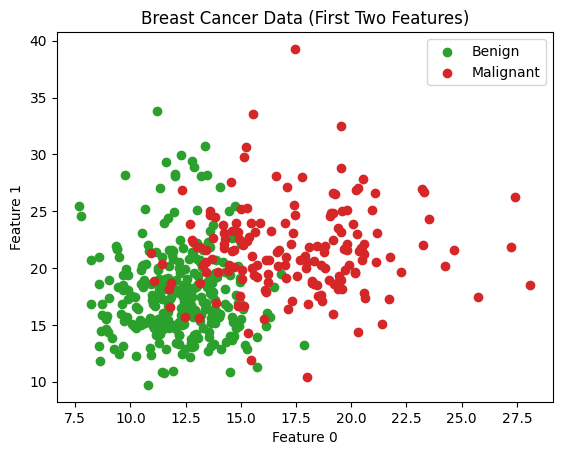

In [71]:
plt.scatter(X_train[y_train ==1,0],X_train[y_train == 1,1],color='tab:green', label='Benign')
plt.scatter(X_train[y_train ==0,0],X_train[y_train == 0,1],color='tab:red', label='Malignant')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.title('Breast Cancer Data (First Two Features)')
plt.legend()
plt.show()

In [72]:
def Euclidean_Distance(b,a):
  return np.sqrt(np.sum(b - a)**2)

In [73]:
class KNN:
  def __init__(self,k):
    self.k = k

  def fit(self,X,y):
    self.X_train = X
    self.y_train = y

  def predict(self,new_points):
    predictions = [self.predict_class(new_point) for new_point in new_points]
    return np.array(predictions)

  def predict_class(self,new_point):
    distances = [Euclidean_Distance(point,new_point) for point in self.X_train]
    k_nearest_indices = np.argsort(distances)[:self.k]
    k_nearest_labels = [self.y_train[i] for i in k_nearest_indices]

    most_common = Counter(k_nearest_labels).most_common(1)[0][0]
    return most_common

In [74]:
knn = KNN(11)
knn.fit(X_train,y_train)
predictions = knn.predict(X_test)
accuracy = accuracy_score(y_test,predictions)
print(accuracy)

0.9473684210526315


# Sklearn KNN model

In [75]:
sklearn_knn = KNeighborsClassifier(n_neighbors=11)

In [76]:
sklearn_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

In [77]:
sklearn_predictions = sklearn_knn.predict(X_test)

In [78]:
sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)
print(f"Scikit-learn KNN model accuracy: {sklearn_accuracy}")

Scikit-learn KNN model accuracy: 0.9824561403508771
